# From Fitting a Line to Drawing a Boundary

## Linear classification, the perceptron, and a PyTorch bridge to logistic regression

In the previous notebook we used a linear model to predict a **continuous** quantity:

$$
\hat{y} = wx + b.
$$

In this notebook we keep almost the same mathematical object, but we change its meaning.

Instead of predicting a number, we ask a yes/no question:

> **Is this detector pulse a real event, or just noise?**

That turns a line into a **decision boundary**.

## Learning goals

By the end of this notebook you should be able to explain and implement:

1. how a linear expression becomes a classifier,
2. the geometry of a decision boundary,
3. the perceptron update rule,
4. why feature scaling matters,
5. how PyTorch implements linear classification using `nn.Linear`,
6. why nonlinear patterns motivate multilayer neural networks.

In [1]:
import math
import random
from pathlib import Path

import numpy as np
import torch
from torch import nn
import matplotlib.pyplot as plt

# Reproducibility
seed = 7
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.set_num_threads(1)
try:
    torch.set_num_interop_threads(1)
except RuntimeError:
    pass

torch.set_default_dtype(torch.float32)

# A clean plotting setup for teaching notebooks
plt.rcParams.update({
    "figure.figsize": (7.2, 5.0),
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

print("PyTorch version:", torch.__version__)

PyTorch version: 2.10.0+cpu


# 1. A small physics story

Imagine a simple detector that records pulses. For each pulse we measure two quantities:

$$
A = \text{pulse amplitude in volts},
$$

$$
\tau = \text{pulse duration in milliseconds}.
$$

Real events tend to produce pulses with larger amplitude and longer duration. Noise tends to be smaller and shorter.

Our task is to learn a rule:

$$
(A, \tau) \longrightarrow \text{noise or real event}.
$$

We shall use the labels

$$
y = 0 \quad \text{for noise},
$$

$$
y = 1 \quad \text{for real event}.
$$

In [2]:
def make_detector_data(n_points=260, margin=0.05):
    """Synthetic linearly separable detector data.

    Features:
        A: pulse amplitude in volts
        tau: pulse duration in milliseconds

    Labels are created using a hidden linear rule with a margin, so that
    the perceptron can really converge.
    """
    X_list, y_list = [], []

    # Hidden rule used only to generate the toy data.
    # Students are supposed to learn an equivalent rule from the points.
    def hidden_score(A, tau):
        return 3.0 * (A - 0.62) + 1.15 * (tau - 1.55)

    while len(X_list) < n_points:
        A = np.random.uniform(0.15, 1.30)      # volts
        tau = np.random.uniform(0.45, 3.00)    # milliseconds
        s = hidden_score(A, tau)

        # Keep only points away from the true boundary.
        # This creates a clean first example of linearly separable data.
        if abs(s) > margin:
            X_list.append([A, tau])
            y_list.append(1 if s > 0 else 0)

    X = torch.tensor(X_list)
    y = torch.tensor(y_list).float()
    return X, y

X_raw, y = make_detector_data()
print("Number of pulses:", len(y))
print("Number of noise pulses:", int((y == 0).sum()))
print("Number of real events:", int((y == 1).sum()))
print("First five measurements [A in V, tau in ms]:")
print(X_raw[:5])

Number of pulses: 260
Number of noise pulses: 91
Number of real events: 169
First five measurements [A in V, tau in ms]:
tensor([[0.2378, 2.4388],
        [0.6542, 2.2948],
        [1.2747, 1.8232],
        [0.7263, 0.6337],
        [0.4587, 1.7247]])


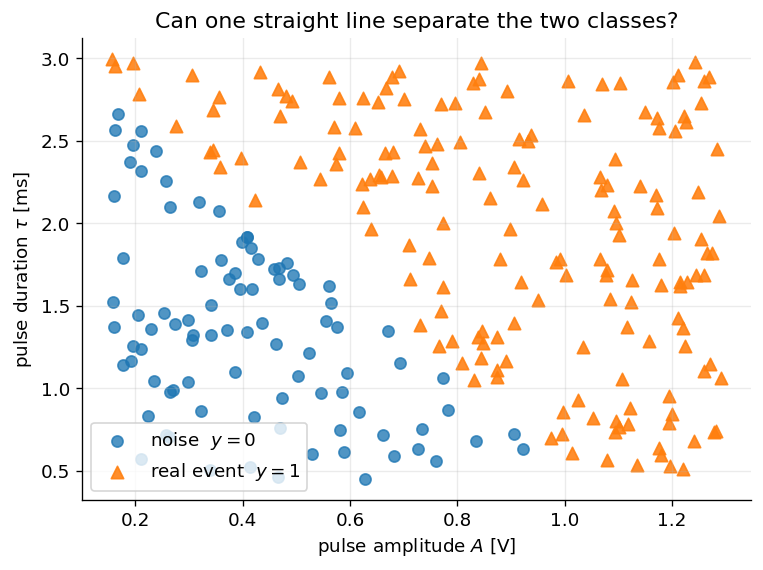

In [3]:
def plot_detector_points(X, y, ax=None, title="Detector pulses"):
    if ax is None:
        fig, ax = plt.subplots()
    X_np = X.detach().cpu().numpy()
    y_np = y.detach().cpu().numpy().astype(int)

    ax.scatter(X_np[y_np == 0, 0], X_np[y_np == 0, 1],
               s=45, alpha=0.78, label="noise  $y=0$", marker="o")
    ax.scatter(X_np[y_np == 1, 0], X_np[y_np == 1, 1],
               s=55, alpha=0.88, label="real event  $y=1$", marker="^")
    ax.set_xlabel("pulse amplitude $A$ [V]")
    ax.set_ylabel("pulse duration $\\tau$ [ms]")
    ax.set_title(title)
    ax.legend(frameon=True)
    return ax

plot_detector_points(X_raw, y, title="Can one straight line separate the two classes?")
plt.show()

# 2. From a fitted line to a decision boundary

In linear regression we used a linear model as a direct prediction:

$$
\hat{y} = wx + b.
$$

For classification we use a similar expression, but now it is a **score**:

$$
z = w_A A + w_\tau \tau + b.
$$

The sign of the score determines the class:

$$
\hat{y} =
\begin{cases}
1, & z > 0, \\
0, & z \leq 0.
\end{cases}
$$

The boundary between the two decisions is the set of points where the model is undecided:

$$
w_A A + w_\tau \tau + b = 0.
$$

In a two-dimensional feature space this is a **line**.

## A note about units and scaling

The two features have different units:

- amplitude is measured in volts,
- duration is measured in milliseconds.

A numerical algorithm does not understand physical units. It only sees numbers.

So before training, we standardize the features:

$$
x_1 = \frac{A - \mu_A}{\sigma_A},
$$

$$
x_2 = \frac{\tau - \mu_\tau}{\sigma_\tau}.
$$

This does **not** change the physics. It only changes the coordinate system in which the algorithm works.

In [4]:
X_mean = X_raw.mean(dim=0)
X_std = X_raw.std(dim=0)
X = (X_raw - X_mean) / X_std

print("Feature means [A, tau]:", X_mean)
print("Feature standard deviations [A, tau]:", X_std)
print("Mean of standardized features:", X.mean(dim=0))
print("Std of standardized features:", X.std(dim=0))

Feature means [A, tau]: tensor([0.7357, 1.7448])
Feature standard deviations [A, tau]: tensor([0.3484, 0.7329])
Mean of standardized features: tensor([ 4.4016e-08, -8.8031e-08])
Std of standardized features: tensor([1., 1.])


Accuracy of random boundary: 0.358


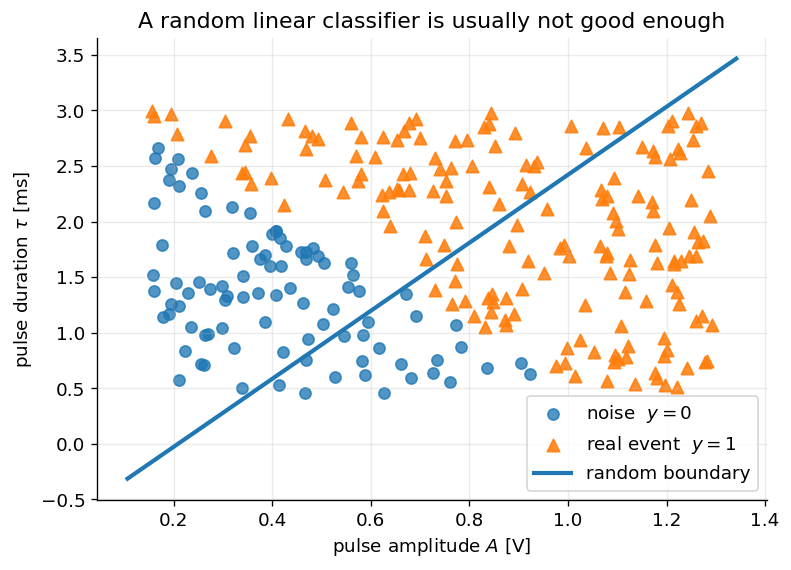

In [5]:
def boundary_tau_from_standardized_weights(A_values, w, b, mean=X_mean, std=X_std):
    """Convert a standardized decision boundary back to raw A-tau coordinates.

    The model is
        z = w0 * (A - mu_A)/sigma_A + w1 * (tau - mu_tau)/sigma_tau + b.

    The boundary is z = 0. Solve for tau.
    """
    w = torch.as_tensor(w).detach().cpu().float()
    b = float(torch.as_tensor(b).detach().cpu())
    A_values = torch.as_tensor(A_values).float()
    if abs(float(w[1])) < 1e-8:
        return torch.full_like(A_values, float("nan"))
    tau_values = mean[1] + std[1] * (-(w[0] * (A_values - mean[0]) / std[0] + b) / w[1])
    return tau_values


def predict_with_step(X_standardized, w, b):
    z = X_standardized @ w + b
    return (z > 0).float()


def accuracy(X_standardized, y, w, b):
    pred = predict_with_step(X_standardized, w, b)
    return (pred == y).float().mean().item()


def plot_boundary_raw(w, b, ax=None, label="decision boundary", linewidth=2.5, alpha=1.0):
    if ax is None:
        fig, ax = plt.subplots()
    A_min, A_max = X_raw[:, 0].min().item() - 0.05, X_raw[:, 0].max().item() + 0.05
    A_grid = torch.linspace(A_min, A_max, 200)
    tau_grid = boundary_tau_from_standardized_weights(A_grid, w, b)
    ax.plot(A_grid.numpy(), tau_grid.numpy(), linewidth=linewidth, alpha=alpha, label=label)
    return ax

# Try a random boundary before learning.
w_random = torch.tensor([-0.8, 0.55])
b_random = torch.tensor(0.1)

fig, ax = plt.subplots()
plot_detector_points(X_raw, y, ax=ax, title="A random linear classifier is usually not good enough")
plot_boundary_raw(w_random, b_random, ax=ax, label="random boundary")
ax.legend(frameon=True)
plt.show()

print(f"Accuracy of random boundary: {accuracy(X, y, w_random, b_random):.3f}")

# 3. The perceptron

The perceptron is one of the simplest learning machines.

It computes a score

$$
z_i = \mathbf{w}\cdot \mathbf{x}_i + b,
$$

then predicts a class using a step function.

For the classical perceptron it is convenient to use labels

$$
y_i \in \{-1, +1\}.
$$

The prediction is correct when

$$
y_i z_i > 0.
$$

If the point is misclassified, meaning

$$
y_i z_i \leq 0,
$$

we update the parameters:

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta y_i \mathbf{x}_i,
$$

$$
b \leftarrow b + \eta y_i.
$$

Here $\eta$ is the learning rate.

The update has a simple geometric meaning: when a point is on the wrong side of the boundary, we rotate and shift the boundary to correct it.

In [6]:
y_pm1 = 2 * y - 1  # convert 0,1 labels into -1,+1 labels

def perceptron_train(X, y_pm1, lr=0.15, epochs=30, shuffle=True):
    w = torch.zeros(X.shape[1])
    b = torch.tensor(0.0)
    history = []

    for epoch in range(1, epochs + 1):
        mistakes = 0
        order = torch.randperm(len(y_pm1)) if shuffle else torch.arange(len(y_pm1))

        for i in order:
            xi = X[i]
            yi = y_pm1[i]
            score = torch.dot(w, xi) + b

            if yi * score <= 0:
                w = w + lr * yi * xi
                b = b + lr * yi
                mistakes += 1

        pred_pm1 = torch.sign(X @ w + b)
        pred_pm1[pred_pm1 == 0] = -1
        acc = (pred_pm1 == y_pm1).float().mean().item()

        history.append({
            "epoch": epoch,
            "w": w.clone(),
            "b": b.clone(),
            "mistakes": mistakes,
            "accuracy": acc,
        })

        if mistakes == 0:
            break

    return w, b, history

w_perc, b_perc, hist = perceptron_train(X, y_pm1, lr=0.15, epochs=40)

print("Learned standardized weights:", w_perc)
print("Learned bias:", b_perc.item())
print("Final perceptron accuracy:", accuracy(X, y, w_perc, b_perc))
print("Number of epochs used:", len(hist))

Learned standardized weights: tensor([1.0884, 0.8164])
Learned bias: 0.6000000238418579
Final perceptron accuracy: 1.0
Number of epochs used: 6


In [7]:
# Show a compact training log.
print("epoch | mistakes | accuracy")
print("------+----------+---------")
for h in hist[:10]:
    print(f"{h['epoch']:5d} | {h['mistakes']:8d} | {h['accuracy']:.3f}")
if len(hist) > 10:
    print("   ...")
    h = hist[-1]
    print(f"{h['epoch']:5d} | {h['mistakes']:8d} | {h['accuracy']:.3f}")

epoch | mistakes | accuracy
------+----------+---------
    1 |       21 | 0.927
    2 |       13 | 0.973
    3 |       12 | 0.942
    4 |        8 | 0.954
    5 |        8 | 1.000
    6 |        0 | 1.000


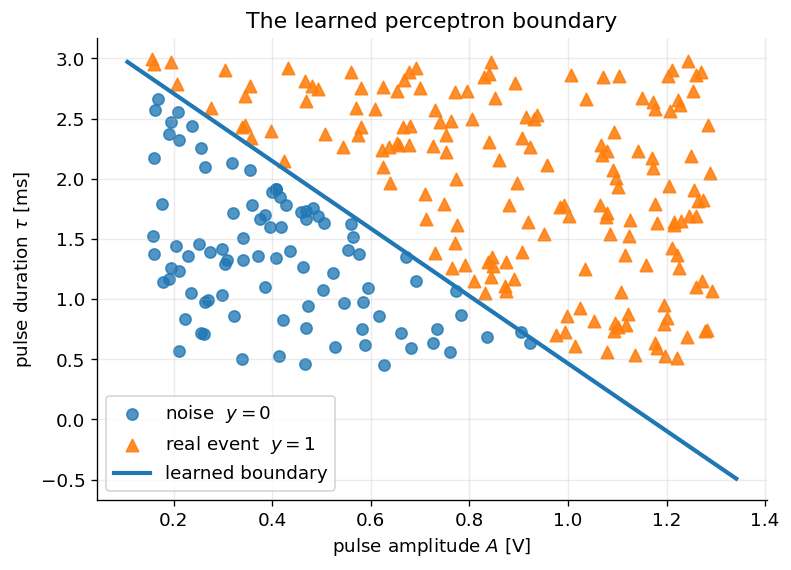

In [8]:
fig, ax = plt.subplots()
plot_detector_points(X_raw, y, ax=ax, title="The learned perceptron boundary")
plot_boundary_raw(w_perc, b_perc, ax=ax, label="learned boundary")
ax.legend(frameon=True)
plt.show()

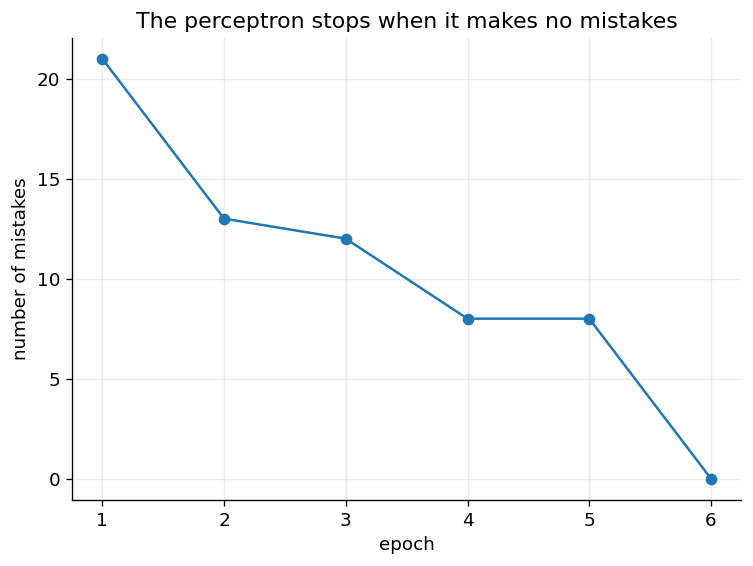

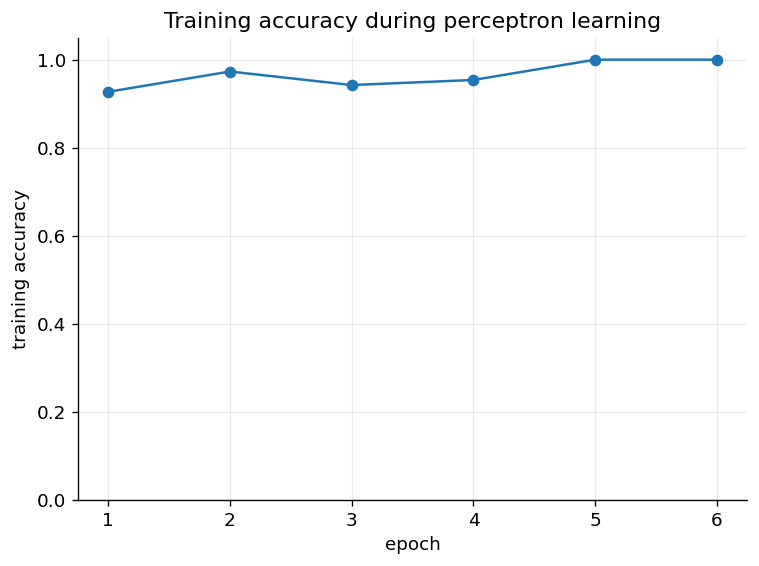

In [9]:
epochs = [h["epoch"] for h in hist]
mistakes = [h["mistakes"] for h in hist]
accuracies = [h["accuracy"] for h in hist]

fig, ax = plt.subplots()
ax.plot(epochs, mistakes, marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("number of mistakes")
ax.set_title("The perceptron stops when it makes no mistakes")
plt.show()

fig, ax = plt.subplots()
ax.plot(epochs, accuracies, marker="o")
ax.set_xlabel("epoch")
ax.set_ylabel("training accuracy")
ax.set_ylim(0.0, 1.05)
ax.set_title("Training accuracy during perceptron learning")
plt.show()

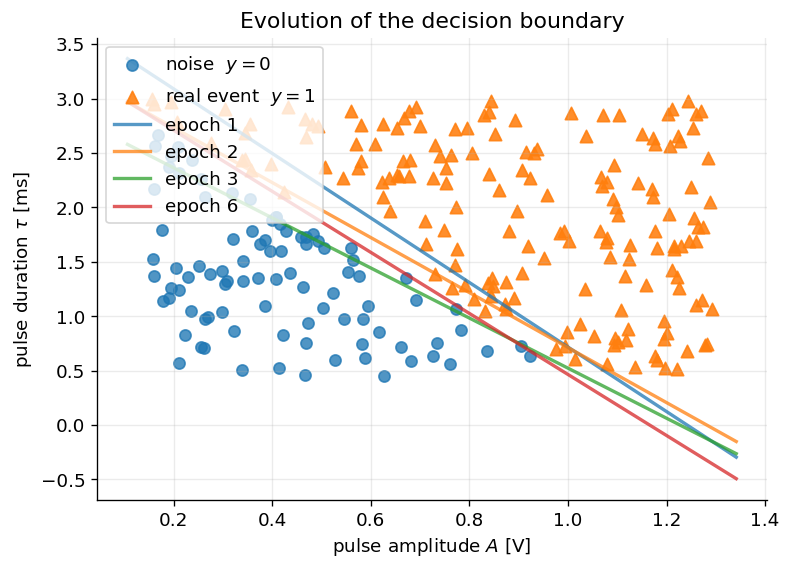

In [10]:
# Visualize how the boundary changes during training.
fig, ax = plt.subplots()
plot_detector_points(X_raw, y, ax=ax, title="Evolution of the decision boundary")

selected_indices = sorted(set([0, min(1, len(hist)-1), min(2, len(hist)-1), len(hist)-1]))
for j in selected_indices:
    h = hist[j]
    plot_boundary_raw(
        h["w"], h["b"], ax=ax,
        label=f"epoch {h['epoch']}", linewidth=2.0, alpha=0.75
    )

ax.legend(frameon=True, loc="upper left")
plt.show()

# 4. Watching one perceptron correction

Let us look at one update more slowly.

Suppose a point has true label $y_i = +1$, but the current model gives it a negative score:

$$
\mathbf{w}\cdot \mathbf{x}_i + b < 0.
$$

Then the point is on the wrong side of the boundary.

The update

$$
\mathbf{w} \leftarrow \mathbf{w} + \eta y_i \mathbf{x}_i
$$

moves the weight vector toward that point.

Misclassified point index: 0
True class: noise
Score before update: 0.6922760605812073
Score after update: -0.6865290403366089


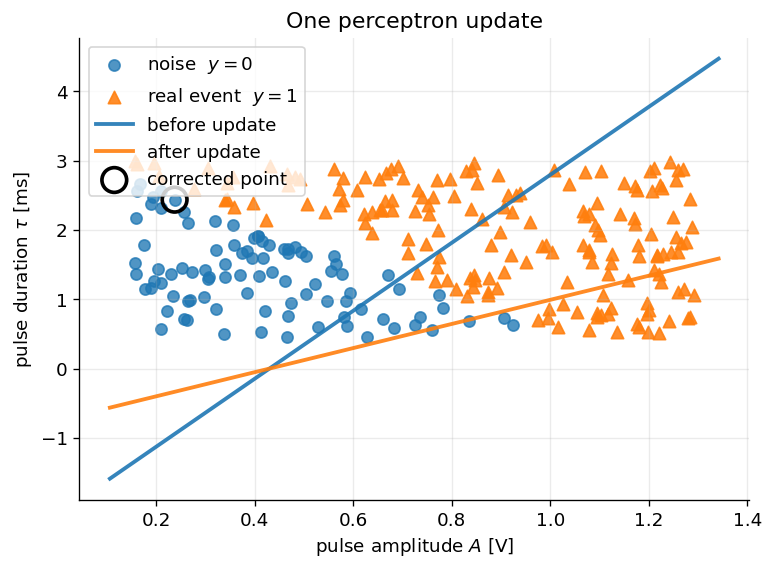

In [11]:
def find_first_mistake(X, y_pm1, w, b):
    for i in range(len(y_pm1)):
        score = torch.dot(w, X[i]) + b
        if y_pm1[i] * score <= 0:
            return i
    return None

w_before = torch.tensor([-0.35, 0.15])
b_before = torch.tensor(0.05)
i_bad = find_first_mistake(X, y_pm1, w_before, b_before)
eta = 0.35

xi = X[i_bad]
yi = y_pm1[i_bad]
w_after = w_before + eta * yi * xi
b_after = b_before + eta * yi

print("Misclassified point index:", i_bad)
print("True class:", "real event" if y[i_bad].item() == 1 else "noise")
print("Score before update:", float(torch.dot(w_before, xi) + b_before))
print("Score after update:", float(torch.dot(w_after, xi) + b_after))

fig, ax = plt.subplots()
plot_detector_points(X_raw, y, ax=ax, title="One perceptron update")
plot_boundary_raw(w_before, b_before, ax=ax, label="before update", linewidth=2.3, alpha=0.9)
plot_boundary_raw(w_after, b_after, ax=ax, label="after update", linewidth=2.3, alpha=0.9)

# Highlight the misclassified point in raw coordinates.
point_raw = X_raw[i_bad]
ax.scatter([point_raw[0]], [point_raw[1]], s=220, facecolors="none", edgecolors="black", linewidths=2.2,
           label="corrected point")
ax.legend(frameon=True, loc="upper left")
plt.show()

# 5. The PyTorch version: linear classification with a differentiable loss

The classical perceptron uses a step function. The step function is intuitive, but it is not differentiable.

Modern neural networks usually replace the hard step with a smooth probability model.

We compute a **logit**:

$$
z = \mathbf{w}\cdot\mathbf{x} + b,
$$

then convert it into a probability using the sigmoid function:

$$
P(y=1\mid \mathbf{x}) = \sigma(z) = \frac{1}{1 + e^{-z}}.
$$

The binary cross-entropy loss is

$$
\mathcal{L}
= -\frac{1}{N}\sum_{i=1}^N
\left[
 y_i \log p_i + (1-y_i)\log(1-p_i)
\right].
$$

In PyTorch, we usually use `BCEWithLogitsLoss`, which combines the sigmoid and the binary cross-entropy in a numerically stable way.

In [12]:
class LinearClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear = nn.Linear(2, 1)

    def forward(self, x):
        # Output shape: (batch, 1). We squeeze to get shape (batch,).
        return self.linear(x).squeeze(-1)

model = LinearClassifier()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.35)

loss_history = []
acc_history = []

for epoch in range(1, 151):
    logits = model(X)
    loss = loss_fn(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    with torch.no_grad():
        probs = torch.sigmoid(model(X))
        preds = (probs > 0.5).float()
        acc = (preds == y).float().mean().item()

    loss_history.append(loss.item())
    acc_history.append(acc)

print("Final loss:", loss_history[-1])
print("Final accuracy:", acc_history[-1])

learned_w = model.linear.weight.detach().flatten()
learned_b = model.linear.bias.detach().squeeze()
print("Learned standardized weights:", learned_w)
print("Learned bias:", learned_b.item())

Final loss: 0.1400984227657318
Final accuracy: 0.9807692170143127
Learned standardized weights: tensor([3.0973, 2.1797])
Learned bias: 1.564414143562317


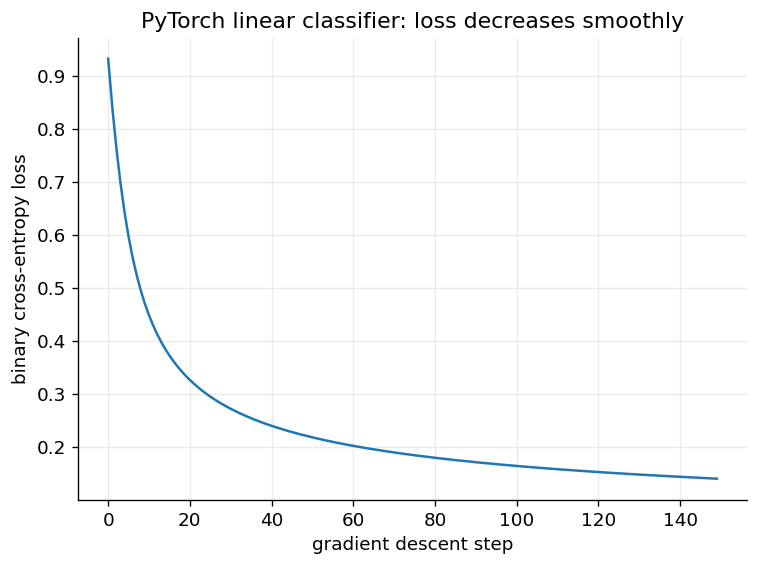

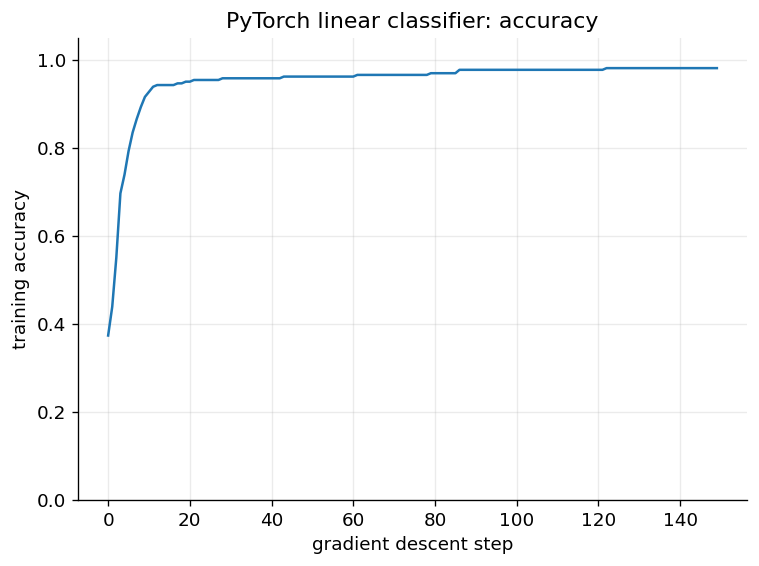

In [13]:
fig, ax = plt.subplots()
ax.plot(loss_history)
ax.set_xlabel("gradient descent step")
ax.set_ylabel("binary cross-entropy loss")
ax.set_title("PyTorch linear classifier: loss decreases smoothly")
plt.show()

fig, ax = plt.subplots()
ax.plot(acc_history)
ax.set_xlabel("gradient descent step")
ax.set_ylabel("training accuracy")
ax.set_ylim(0.0, 1.05)
ax.set_title("PyTorch linear classifier: accuracy")
plt.show()

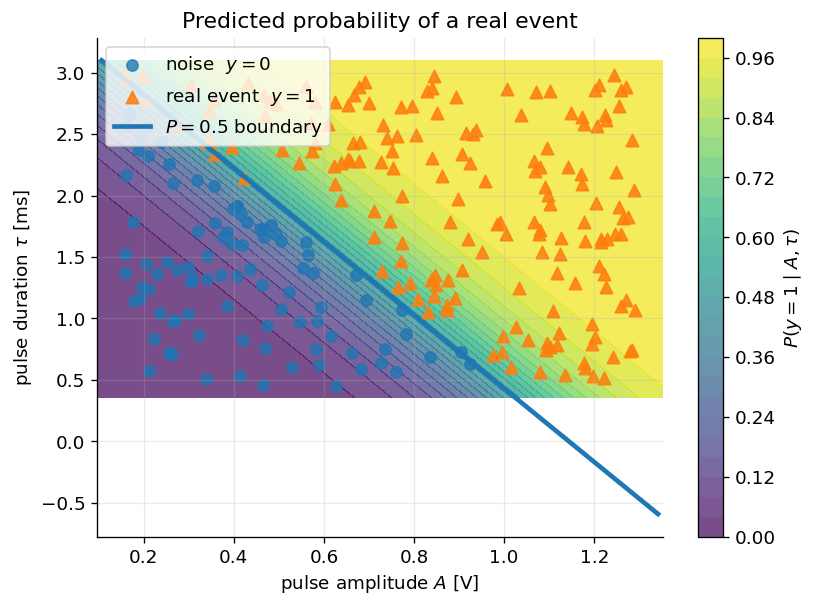

In [14]:
def plot_probability_background(model, X_raw, y, title="Predicted probability of a real event"):
    A_min, A_max = X_raw[:, 0].min().item() - 0.06, X_raw[:, 0].max().item() + 0.06
    tau_min, tau_max = X_raw[:, 1].min().item() - 0.10, X_raw[:, 1].max().item() + 0.10

    A_grid = torch.linspace(A_min, A_max, 170)
    tau_grid = torch.linspace(tau_min, tau_max, 170)
    AA, TT = torch.meshgrid(A_grid, tau_grid, indexing="xy")
    X_grid_raw = torch.stack([AA.reshape(-1), TT.reshape(-1)], dim=1)
    X_grid = (X_grid_raw - X_mean) / X_std

    with torch.no_grad():
        probs = torch.sigmoid(model(X_grid)).reshape(AA.shape)

    fig, ax = plt.subplots(figsize=(7.6, 5.4))
    im = ax.contourf(AA.numpy(), TT.numpy(), probs.numpy(), levels=25, alpha=0.72)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("$P(y=1\mid A,\\tau)$")

    plot_detector_points(X_raw, y, ax=ax, title=title)
    plot_boundary_raw(learned_w, learned_b, ax=ax, label="$P=0.5$ boundary", linewidth=2.8)
    ax.legend(frameon=True, loc="upper left")
    plt.show()

plot_probability_background(model, X_raw, y)

## Perceptron vs logistic regression

The two models use the same linear score:

$$
z = \mathbf{w}\cdot \mathbf{x} + b.
$$

The classical perceptron makes a hard decision:

$$
\hat{y} = H(z).
$$

Logistic regression gives a probability:

$$
p = \sigma(z).
$$

This probability view is important because it leads naturally to differentiable losses and gradient-based training.

That is the bridge to modern neural networks.

# 6. When a line is not enough

A single perceptron can only draw one straight boundary.

But many physical classification problems are not linearly separable.

For example, suppose the relevant events lie in a ring-shaped region of feature space. A single straight line cannot enclose a ring.

This is where the next big idea appears:

> combine many linear units with nonlinear activation functions.

That is the beginning of the multilayer perceptron.

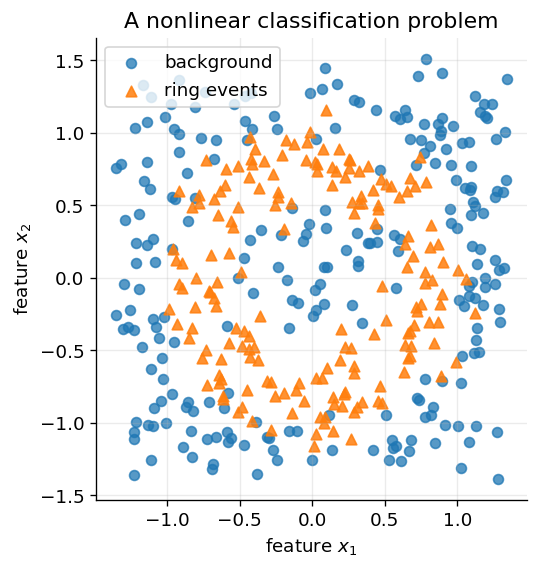

In [15]:
def make_ring_data(n=420, noise=0.08):
    """A simple nonlinear two-class dataset in dimensionless coordinates."""
    X = 2.6 * torch.rand(n, 2) - 1.3
    r = torch.sqrt((X ** 2).sum(dim=1))
    y = ((r > 0.55) & (r < 1.05)).float()

    # Add a little measurement noise.
    X = X + noise * torch.randn_like(X)
    return X, y

X_ring, y_ring = make_ring_data()

fig, ax = plt.subplots()
y_np = y_ring.numpy().astype(int)
ax.scatter(X_ring[y_np == 0, 0], X_ring[y_np == 0, 1], s=35, alpha=0.75, label="background")
ax.scatter(X_ring[y_np == 1, 0], X_ring[y_np == 1, 1], s=40, alpha=0.85, label="ring events", marker="^")
ax.set_xlabel("feature $x_1$")
ax.set_ylabel("feature $x_2$")
ax.set_title("A nonlinear classification problem")
ax.set_aspect("equal", adjustable="box")
ax.legend(frameon=True)
plt.show()

In [16]:
# Try a linear classifier on the nonlinear ring data.
linear_ring = nn.Linear(2, 1)
optimizer = torch.optim.Adam(linear_ring.parameters(), lr=0.05)
loss_fn = nn.BCEWithLogitsLoss()

for step in range(260):
    logits = linear_ring(X_ring).squeeze(-1)
    loss = loss_fn(logits, y_ring)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

with torch.no_grad():
    probs = torch.sigmoid(linear_ring(X_ring).squeeze(-1))
    preds = (probs > 0.5).float()
    linear_acc = (preds == y_ring).float().mean().item()

print(f"Accuracy of a single linear classifier on the ring data: {linear_acc:.3f}")

Accuracy of a single linear classifier on the ring data: 0.564


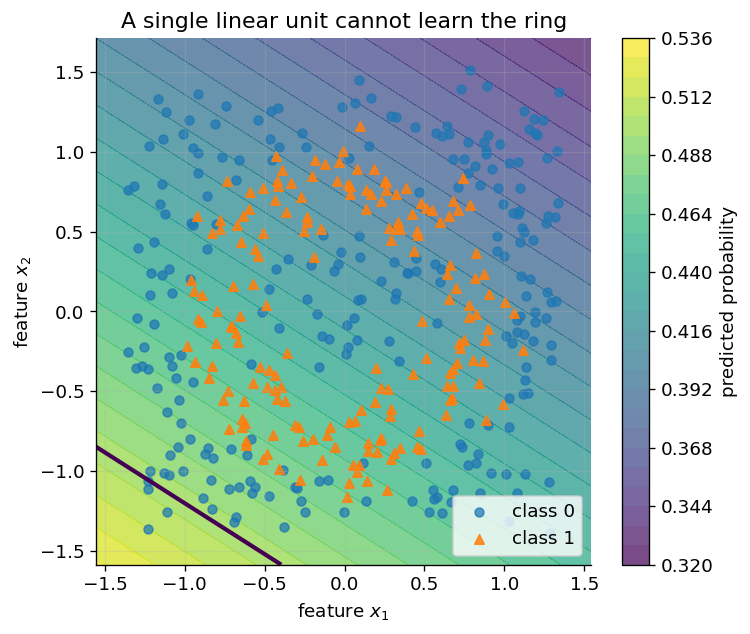

In [17]:
def plot_2d_probability(model, X_data, y_data, title):
    x1_min, x1_max = X_data[:, 0].min().item() - 0.2, X_data[:, 0].max().item() + 0.2
    x2_min, x2_max = X_data[:, 1].min().item() - 0.2, X_data[:, 1].max().item() + 0.2
    x1 = torch.linspace(x1_min, x1_max, 170)
    x2 = torch.linspace(x2_min, x2_max, 170)
    XX, YY = torch.meshgrid(x1, x2, indexing="xy")
    grid = torch.stack([XX.reshape(-1), YY.reshape(-1)], dim=1)

    with torch.no_grad():
        logits = model(grid).squeeze(-1)
        probs = torch.sigmoid(logits).reshape(XX.shape)

    fig, ax = plt.subplots(figsize=(6.7, 5.7))
    im = ax.contourf(XX.numpy(), YY.numpy(), probs.numpy(), levels=25, alpha=0.72)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("predicted probability")

    y_np = y_data.numpy().astype(int)
    ax.scatter(X_data[y_np == 0, 0], X_data[y_np == 0, 1], s=28, alpha=0.72, label="class 0")
    ax.scatter(X_data[y_np == 1, 0], X_data[y_np == 1, 1], s=32, alpha=0.85, marker="^", label="class 1")
    ax.contour(XX.numpy(), YY.numpy(), probs.numpy(), levels=[0.5], linewidths=2.5)
    ax.set_xlabel("feature $x_1$")
    ax.set_ylabel("feature $x_2$")
    ax.set_title(title)
    ax.set_aspect("equal", adjustable="box")
    ax.legend(frameon=True)
    plt.show()

plot_2d_probability(linear_ring, X_ring, y_ring, "A single linear unit cannot learn the ring")

Accuracy of a small MLP on the ring data: 0.917


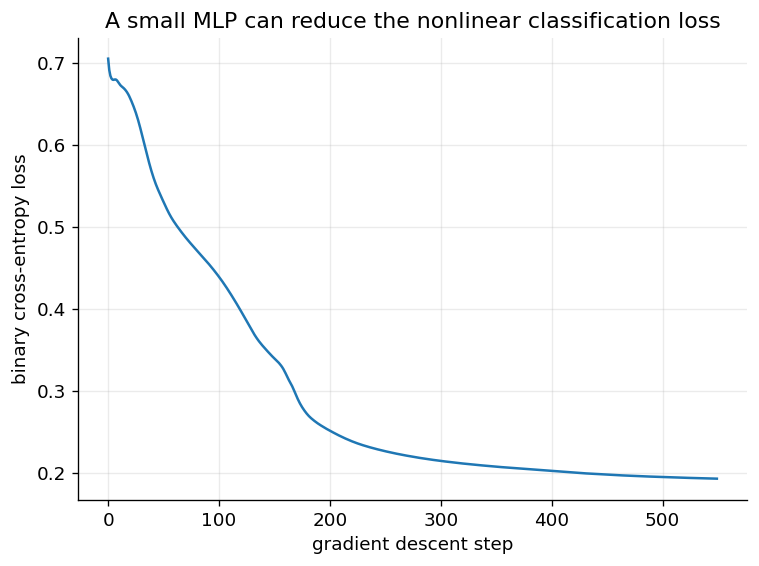

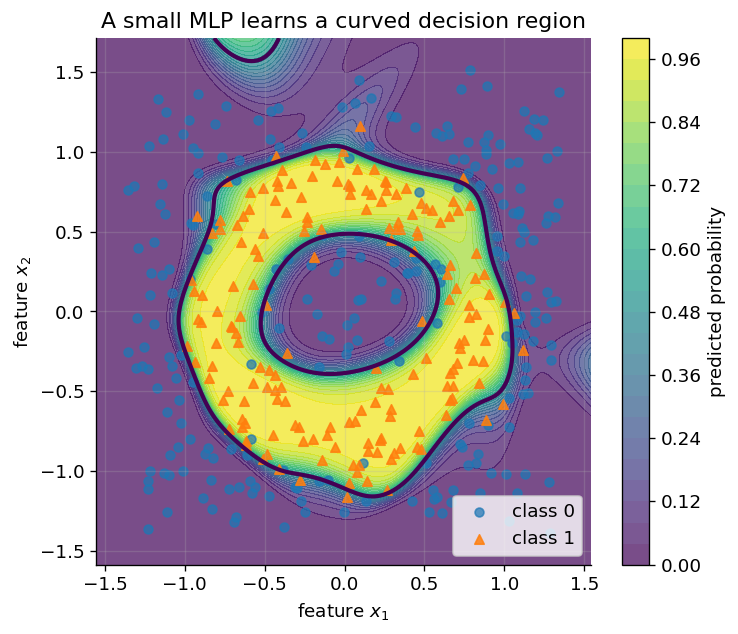

In [18]:
# A tiny MLP teaser: one hidden layer can bend the boundary.
mlp_ring = nn.Sequential(
    nn.Linear(2, 16),
    nn.Tanh(),
    nn.Linear(16, 1),
)

optimizer = torch.optim.Adam(mlp_ring.parameters(), lr=0.03)
loss_fn = nn.BCEWithLogitsLoss()

mlp_losses = []
for step in range(550):
    logits = mlp_ring(X_ring).squeeze(-1)
    loss = loss_fn(logits, y_ring)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    mlp_losses.append(loss.item())

with torch.no_grad():
    probs = torch.sigmoid(mlp_ring(X_ring).squeeze(-1))
    preds = (probs > 0.5).float()
    mlp_acc = (preds == y_ring).float().mean().item()

print(f"Accuracy of a small MLP on the ring data: {mlp_acc:.3f}")

fig, ax = plt.subplots()
ax.plot(mlp_losses)
ax.set_xlabel("gradient descent step")
ax.set_ylabel("binary cross-entropy loss")
ax.set_title("A small MLP can reduce the nonlinear classification loss")
plt.show()

plot_2d_probability(mlp_ring, X_ring, y_ring, "A small MLP learns a curved decision region")

# 7. Summary

The linear expression

$$
z = \mathbf{w}\cdot\mathbf{x} + b
$$

is the central object of this notebook.

It can be used in different ways:

| Model | Meaning of output | Training idea |
|---|---|---|
| Linear regression | continuous prediction | minimize mean squared error |
| Perceptron | hard class decision | correct mistakes directly |
| Logistic regression | probability of class 1 | minimize binary cross-entropy |
| MLP | nonlinear decision regions | stack linear layers and nonlinearities |

The perceptron is the conceptual bridge from linear regression to neural networks.

The next natural step is the **multilayer perceptron**:

$$
\mathbf{h} = \phi(W_1\mathbf{x} + \mathbf{b}_1),
$$

$$
\hat{y} = \sigma(W_2\mathbf{h} + b_2).
$$

The new ingredient is the nonlinear activation function $\phi$.

# Exercises for students

1. Change the perceptron learning rate $\eta$. What happens if it is very small? What happens if it is very large?

2. Train the perceptron without standardizing the features. Does the training behave differently?

3. Reduce the margin in `make_detector_data`. At what point does the data become hard to separate?

4. In the PyTorch logistic-regression section, replace `SGD` with `Adam`. Compare the loss curves.

5. In the ring example, change the number of hidden units in the MLP from 16 to 2, 4, 8, and 32. How does the decision boundary change?

6. Physics extension: invent two features from an experiment you know and design a synthetic classification problem around them.